objetivo del proyecto: identificar a operadores ineficientes 
metricas para determinar ineficiencia:
#### 1. Gran cantidad de llamadas entrantes perdidas (internas y externas).
#### 2. Tiempo de espera prolongado para las llamadas entrantes.
#### 3. Número reducido de llamadas salientes.

In [207]:
#librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

In [208]:
#cargar data
data = pd.read_csv('/datasets/telecom_dataset_us.csv')
clientes = pd.read_csv('/datasets/telecom_clients_us.csv')

In [209]:
print(data.head())

   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  


In [210]:
print(clientes.head())

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16


In [211]:

print(data)

       user_id                       date direction internal  operator_id  \
0       166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1       166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2       166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3       166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4       166377  2019-08-05 00:00:00+03:00       out    False     880022.0   
...        ...                        ...       ...      ...          ...   
53897   168606  2019-11-10 00:00:00+03:00       out     True     957922.0   
53898   168606  2019-11-11 00:00:00+03:00       out     True     957922.0   
53899   168606  2019-11-15 00:00:00+03:00       out     True     957922.0   
53900   168606  2019-11-15 00:00:00+03:00       out     True     957922.0   
53901   168606  2019-11-19 00:00:00+03:00        in    False          NaN   

       is_missed_call  calls_count  call_duration  total_call_duration  
0 

In [212]:
#tipo de datos y datos nulos 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [213]:
print(data['operator_id'].isnull().sum())

8172


sobre los tipos de datos hare las siguientes modificaciones:
cambiar date a datetime
operator_id a int64
internal a booleano
La unica columna que tiene valores nulos es operator_id, ya que este analisis se basa en ellos, la información que no que no se puede ligar a un operador no es valiosa, por lo que procedere a eliminarla.

In [214]:
#eliminar valores ausentes 
data_1 = data.dropna().copy()
print(data_1.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45670 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              45670 non-null  int64  
 1   date                 45670 non-null  object 
 2   direction            45670 non-null  object 
 3   internal             45670 non-null  object 
 4   operator_id          45670 non-null  float64
 5   is_missed_call       45670 non-null  bool   
 6   calls_count          45670 non-null  int64  
 7   call_duration        45670 non-null  int64  
 8   total_call_duration  45670 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.2+ MB
None


In [215]:
#cambio de tipo de datos 

data_1['date'] = pd.to_datetime(data_1['date']).dt.tz_convert(None)
data_1['operator_id'] = data_1['operator_id'].astype('int64')
data_1['internal'] = data_1['internal'].astype('bool')

In [216]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45670 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45670 non-null  int64         
 1   date                 45670 non-null  datetime64[ns]
 2   direction            45670 non-null  object        
 3   internal             45670 non-null  bool          
 4   operator_id          45670 non-null  int64         
 5   is_missed_call       45670 non-null  bool          
 6   calls_count          45670 non-null  int64         
 7   call_duration        45670 non-null  int64         
 8   total_call_duration  45670 non-null  int64         
dtypes: bool(2), datetime64[ns](1), int64(5), object(1)
memory usage: 2.9+ MB


In [217]:
# ahora con clientes
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


solo necesitamos cambiar lo date_start a datetime

In [218]:
clientes['date_start'] = pd.to_datetime(clientes['date_start'])
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB


In [219]:
# valores duplicados 
print('valores duplcados en data:',data_1.duplicated().sum())

valores duplcados en data: 4179


In [220]:
# verificar si hay filas repetidas explicitamente 
print(data_1.sort_values(['user_id','date','direction','internal','operator_id','is_missed_call','is_missed_call','call_duration','total_call_duration']))

       user_id                date direction  internal  operator_id  \
5       166377 2019-08-04 21:00:00       out     False       880020   
6       166377 2019-08-04 21:00:00       out     False       880020   
8       166377 2019-08-04 21:00:00       out     False       880020   
4       166377 2019-08-04 21:00:00       out     False       880022   
3       166377 2019-08-04 21:00:00       out      True       880020   
...        ...                 ...       ...       ...          ...   
53896   168606 2019-11-09 21:00:00       out      True       957922   
53897   168606 2019-11-09 21:00:00       out      True       957922   
53898   168606 2019-11-10 21:00:00       out      True       957922   
53899   168606 2019-11-14 21:00:00       out      True       957922   
53900   168606 2019-11-14 21:00:00       out      True       957922   

       is_missed_call  calls_count  call_duration  total_call_duration  
5               False            2              3                   29  
6

Como podemos obversar la fila 6 y 8 son iguales explicitamente por lo que si existen valores duplicados explicitos, creo que esto es un error ya que la probabilidad de que un operado haga exactamente el mismo número de llamadas, con la misma duración, con el mismo origen en la misma hora es casi nula. procedere a eliminar los valores duplicados

In [221]:
#data ya sin valores duplicados y sin valores nulos 
data_2 = data_1.drop_duplicates()
print('valores duplicados en nueva data:',data_2.duplicated().sum())

valores duplicados en nueva data: 0


In [222]:
#verificar duplicados en clientes 
print(clientes.duplicated().sum())

0


In [223]:
#verificar mas datos
print('verificar que solo haya 2 direcciones',data_2['direction'].unique())
print()
print(data_2[['calls_count','call_duration','total_call_duration']].describe())

verificar que solo haya 2 direcciones ['out' 'in']

        calls_count  call_duration  total_call_duration
count  41491.000000   41491.000000         41491.000000
mean      16.921381    1010.940011          1323.153238
std       59.786187    4066.666485          4788.953155
min        1.000000       0.000000             0.000000
25%        1.000000       0.000000            67.000000
50%        4.000000     106.000000           289.000000
75%       14.000000     772.000000          1107.000000
max     4817.000000  144395.000000        166155.000000


los valores númericos parecen no tener valores anormales como negativos. hay valores muy altos, investigaremos en el EDA los datos atipicos.

In [224]:
#EDA

In [225]:
#explorar usuarios unicos en cada df
print("Usuarios únicos en data_2:", data_2['user_id'].nunique())
print("Usuarios únicos en clientes:", clientes['user_id'].nunique())

Usuarios únicos en data_2: 290
Usuarios únicos en clientes: 732


In [226]:
usuarios_sin_info = set(data_2['user_id']) - set(clientes['user_id'])
print("Usuarios en data_2 que NO están en clientes:", len(usuarios_sin_info))

Usuarios en data_2 que NO están en clientes: 0


In [227]:
# merge left join de tablas 
data_m = data_2.merge(clientes, on='user_id',how='left')
print(data_m)

       user_id                date direction  internal  operator_id  \
0       166377 2019-08-04 21:00:00       out      True       880022   
1       166377 2019-08-04 21:00:00       out      True       880020   
2       166377 2019-08-04 21:00:00       out      True       880020   
3       166377 2019-08-04 21:00:00       out     False       880022   
4       166377 2019-08-04 21:00:00       out     False       880020   
...        ...                 ...       ...       ...          ...   
41486   168606 2019-11-08 21:00:00       out     False       957922   
41487   168606 2019-11-09 21:00:00       out      True       957922   
41488   168606 2019-11-09 21:00:00       out      True       957922   
41489   168606 2019-11-10 21:00:00       out      True       957922   
41490   168606 2019-11-14 21:00:00       out      True       957922   

       is_missed_call  calls_count  call_duration  total_call_duration  \
0                True            3              0                    5   

In [228]:
#enriquecer tabla 
#columna con solo la fecha 
data_m['solo_date'] = data_m['date'].dt.date
data_m['mes'] = data_m['date'].dt.month
data_m['vida_cliente'] = data_m['date'].max().date() -data_m['date_start'].dt.date
print(data_m)

       user_id                date direction  internal  operator_id  \
0       166377 2019-08-04 21:00:00       out      True       880022   
1       166377 2019-08-04 21:00:00       out      True       880020   
2       166377 2019-08-04 21:00:00       out      True       880020   
3       166377 2019-08-04 21:00:00       out     False       880022   
4       166377 2019-08-04 21:00:00       out     False       880020   
...        ...                 ...       ...       ...          ...   
41486   168606 2019-11-08 21:00:00       out     False       957922   
41487   168606 2019-11-09 21:00:00       out      True       957922   
41488   168606 2019-11-09 21:00:00       out      True       957922   
41489   168606 2019-11-10 21:00:00       out      True       957922   
41490   168606 2019-11-14 21:00:00       out      True       957922   

       is_missed_call  calls_count  call_duration  total_call_duration  \
0                True            3              0                    5   

In [229]:
#llamdas por operador 
lxo = data_m.groupby('operator_id')['calls_count'].sum().reset_index()

print(lxo.sort_values('calls_count',ascending = False))
print()
print(lxo.describe())

     operator_id  calls_count
29        885890        60221
28        885876        59429
583       929428        23754
551       925922        20021
317       908640        14239
..           ...          ...
871       946020            1
872       946032            1
875       946468            1
880       947306            1
842       945274            1

[1092 rows x 2 columns]

         operator_id   calls_count
count    1092.000000   1092.000000
mean   925517.543956    642.934982
std     22854.532209   2889.647014
min    879896.000000      1.000000
25%    906393.500000     10.000000
50%    925105.000000     72.000000
75%    944211.500000    493.750000
max    973286.000000  60221.000000


Hay operadores con muchisimas llamadas y tambien algunos con muy pocas. EL promedio de llamadas por operador es de 642, el 50% de los operadores ha realizado menos de 72 llamadas y el 75% maximo 493, el maximo de 60221 llamadas llama mucho mi atención, tendremos que analizar a operadores con llamadas exageradas, para poder determinar si son valores a tipicos que puedan afectar a nuestro analisis.

tambien el 25% de los operadores ha realizado de 10 a 1 llamadas, es importate tener en mente que estos operadores talvez estan en fase de capacitación.

In [230]:
# agrupar por operador y fecha para tener una vision más completa de las llamadas en rangos de fechas 

op_llam_por_fecha = data_m.groupby(['operator_id','solo_date'])['calls_count'].sum().reset_index()
print(op_llam_por_fecha.sort_values(['operator_id','solo_date']))

       operator_id   solo_date  calls_count
0           879896  2019-08-01           13
1           879896  2019-08-02           11
2           879896  2019-08-03            2
3           879896  2019-08-04           29
4           879896  2019-08-05           52
...            ...         ...          ...
19640       972412  2019-11-27           34
19641       972460  2019-11-26           12
19642       972460  2019-11-27           39
19643       973120  2019-11-26            3
19644       973286  2019-11-27            2

[19645 rows x 3 columns]


In [231]:
dias_llam_o = op_llam_por_fecha.groupby('operator_id').agg({'solo_date':'count','calls_count':'sum'}).reset_index()
#promedio de llamadas diarias
dias_llam_o['pro_llam_d'] = (dias_llam_o['calls_count']/  dias_llam_o['solo_date']).astype('int64')
dias_llam_o_or = dias_llam_o.sort_values('pro_llam_d', ascending =False)
print(dias_llam_o_or)
print(dias_llam_o_or.describe())

     operator_id  solo_date  calls_count  pro_llam_d
551       925922         24        20021         834
29        885890         80        60221         752
317       908640         19        14239         749
583       929428         33        23754         719
28        885876         97        59429         612
..           ...        ...          ...         ...
880       947306          1            1           1
469       919896          3            5           1
472       919956         11           12           1
875       946468          1            1           1
546       925106         14           21           1

[1092 rows x 4 columns]
         operator_id    solo_date   calls_count   pro_llam_d
count    1092.000000  1092.000000   1092.000000  1092.000000
mean   925517.543956    17.989927    642.934982    25.658425
std     22854.532209    18.770379   2889.647014    62.120397
min    879896.000000     1.000000      1.000000     1.000000
25%    906393.500000     3.750000 

El promdeio de llamdas por dia es de 25, pero solo el 25% de los operadores logra tener mas de 23 llamadas al dia, es interesante ver como solo 25% de los operadores acaparan todas las llamadas.
El operador más longevo es de 97 dias y el mas reciente de 1 dia, con un promedio de 17 dias, solo un 25% de los operadores tiene más de 26 dias.


In [232]:
#
print(dias_llam_o_or)

     operator_id  solo_date  calls_count  pro_llam_d
551       925922         24        20021         834
29        885890         80        60221         752
317       908640         19        14239         749
583       929428         33        23754         719
28        885876         97        59429         612
..           ...        ...          ...         ...
880       947306          1            1           1
469       919896          3            5           1
472       919956         11           12           1
875       946468          1            1           1
546       925106         14           21           1

[1092 rows x 4 columns]


### metricas de ineficiencia 
Gran cantidad de llamadas entrantes perdidas (internas y externas).
Para poder sacar un numero excato de llamadas perdidas, selccionaremos todas las llamadas is_missed_call=true de cualquier direccion. podemos sacar un porcentaje dividiendo entre el numero total de llamadas.

In [233]:
llam_dire = data_m.groupby(['operator_id','direction','is_missed_call'])['calls_count'].sum().reset_index()
in_true = llam_dire[(llam_dire['direction']=='in') & (llam_dire['is_missed_call']== True)]
in_true_or = in_true.sort_values('calls_count',ascending=False)
in_true_or.columns = ['operator_id','direction','is_missed_call','missing_calls']
print(in_true_or)


      operator_id direction  is_missed_call  missing_calls
919        913942        in            True             52
1946       940588        in            True             30
2064       944226        in            True             30
75         885890        in            True             26
2048       944216        in            True             24
...           ...       ...             ...            ...
1310       924546        in            True              1
1318       924928        in            True              1
1322       924930        in            True              1
1340       924948        in            True              1
2589       969272        in            True              1

[239 rows x 4 columns]


In [234]:
# df donde esten todo los datos de los operadores, total de llamadas, dias trabajas, promedio por dias y llamadas perdidas
data_ope = dias_llam_o_or.merge(in_true_or[['operator_id','missing_calls']], on='operator_id',how='left')
print(data_ope)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls
0          925922         24        20021         834           10.0
1          885890         80        60221         752           26.0
2          908640         19        14239         749            NaN
3          929428         33        23754         719            NaN
4          885876         97        59429         612           20.0
...           ...        ...          ...         ...            ...
1087       947306          1            1           1            NaN
1088       919896          3            5           1            1.0
1089       919956         11           12           1            NaN
1090       946468          1            1           1            NaN
1091       925106         14           21           1            NaN

[1092 rows x 5 columns]


In [235]:
# tiempo de espera prolongado para las llamadas entrantes 
llam_direcion_tiempo = data_m.groupby(['operator_id','direction']).agg({'call_duration':'sum','total_call_duration':'sum'}).reset_index()
llamdas_entrates_tiempo = llam_direcion_tiempo[llam_direcion_tiempo['direction']=='in'].copy()
llamdas_entrates_tiempo['time_wating_in'] = llamdas_entrates_tiempo['total_call_duration'] - llamdas_entrates_tiempo['call_duration']
llamdas_entrates_tiempo.columns = ['operator_id','direction','call_duration_in','total_call_duration_in','time_wating_in']
print(llamdas_entrates_tiempo)

      operator_id direction  call_duration_in  total_call_duration_in  \
0          879896        in              5616                    6190   
2          879898        in              6351                    8024   
4          880020        in               299                     353   
6          880022        in               512                     624   
8          880026        in              1587                    1730   
...           ...       ...               ...                     ...   
1626       971102        in             10612                   11964   
1627       971354        in               743                     827   
1630       972412        in               120                     145   
1632       972460        in                14                      18   
1635       973286        in                17                     105   

      time_wating_in  
0                574  
2               1673  
4                 54  
6                112  
8       

In [236]:
# agregar el tiempo de espera a nuestra tabla de operadores 
data_ope_2 = data_ope.merge(llamdas_entrates_tiempo, on ='operator_id',how='left')
print(data_ope_2)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
0          925922         24        20021         834           10.0   
1          885890         80        60221         752           26.0   
2          908640         19        14239         749            NaN   
3          929428         33        23754         719            NaN   
4          885876         97        59429         612           20.0   
...           ...        ...          ...         ...            ...   
1087       947306          1            1           1            NaN   
1088       919896          3            5           1            1.0   
1089       919956         11           12           1            NaN   
1090       946468          1            1           1            NaN   
1091       925106         14           21           1            NaN   

     direction  call_duration_in  total_call_duration_in  time_wating_in  
0           in           32678.0                 35490.0    

In [237]:
# numero reducido de llamdas salientes 
llam_out = llam_dire[llam_dire['direction']=='out'].copy()
print(llam_out)
llam_out_total = llam_out.groupby('operator_id')['calls_count'].sum().reset_index()
llam_out_total.columns = ['operator_id','calls_out']
print(llam_out_total)

      operator_id direction  is_missed_call  calls_count
1          879896       out           False          621
2          879896       out            True          251
4          879898       out           False         4849
5          879898       out            True         2360
7          880020       out           False           16
...           ...       ...             ...          ...
2633       972412       out            True           25
2635       972460       out           False           22
2636       972460       out            True           28
2637       973120       out           False            1
2638       973120       out            True            2

[1648 rows x 4 columns]
     operator_id  calls_out
0         879896        872
1         879898       7209
2         880020         38
3         880022        189
4         880026       2208
..           ...        ...
877       972408          6
878       972410         77
879       972412         60
880       9

In [238]:
data_ope_3 = data_ope_2.merge(llam_out_total,on ='operator_id',how='left')
data_ope_3_or = data_ope_3.sort_values(['missing_calls','time_wating_in'], ascending = False)
print(data_ope_3)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
0          925922         24        20021         834           10.0   
1          885890         80        60221         752           26.0   
2          908640         19        14239         749            NaN   
3          929428         33        23754         719            NaN   
4          885876         97        59429         612           20.0   
...           ...        ...          ...         ...            ...   
1087       947306          1            1           1            NaN   
1088       919896          3            5           1            1.0   
1089       919956         11           12           1            NaN   
1090       946468          1            1           1            NaN   
1091       925106         14           21           1            NaN   

     direction  call_duration_in  total_call_duration_in  time_wating_in  \
0           in           32678.0                 35490.0   

In [239]:
print(data_ope_3.describe())

         operator_id    solo_date   calls_count   pro_llam_d  missing_calls  \
count    1092.000000  1092.000000   1092.000000  1092.000000     239.000000   
mean   925517.543956    17.989927    642.934982    25.658425       3.870293   
std     22854.532209    18.770379   2889.647014    62.120397       5.944060   
min    879896.000000     1.000000      1.000000     1.000000       1.000000   
25%    906393.500000     3.750000     10.000000     2.000000       1.000000   
50%    925105.000000    12.000000     72.000000     5.000000       2.000000   
75%    944211.500000    26.250000    493.750000    23.000000       4.000000   
max    973286.000000    97.000000  60221.000000   834.000000      52.000000   

       call_duration_in  total_call_duration_in  time_wating_in     calls_out  
count        754.000000              754.000000      754.000000    882.000000  
mean       12622.086207            14256.435013     1634.348806    689.731293  
std        34031.994184            37483.364796 

el promedio del tiempo que deja el operador en espera a personas es de 1634 segundos, hay maximos de hasta 52795 segundos y minimos de un segundo.
el primedio de llamdas realizadas es de 689 por operador, pero solo el 25% de los operadores tiene mas de 597 llamadas salientes, hay numeros muy altos como 58977 llamadas salientes de un solo operador.
el promedio de llamadas perdidas es de 4, con maximos de 52 y minimos de 1.


tenemos que darnos un espacio para tratar los valores atipicos, pero primero analizemos los datos para ver si estos son errores o simplemente son operadores muy activo o en el caso contrario muy ineficientes 

In [240]:
# llamadas por dia 
#mas de 25 llamdas por dia, q3
llam_25 = data_ope_3_or[data_ope_3_or['pro_llam_d']>25]
print(llam_25[['operator_id','pro_llam_d']].sort_values('pro_llam_d',ascending=False))
print(llam_25['pro_llam_d'].describe())

     operator_id  pro_llam_d
0         925922         834
1         885890         752
2         908640         749
3         929428         719
4         885876         612
..           ...         ...
247       937708          27
249       919790          27
251       902532          27
253       904202          26
254       913788          26

[255 rows x 2 columns]
count    255.000000
mean      92.113725
std      103.335851
min       26.000000
25%       40.500000
50%       67.000000
75%      113.000000
max      834.000000
Name: pro_llam_d, dtype: float64


In [241]:
op_detalle = data_m[data_m['operator_id'] == 925922]
print(op_detalle[['date', 'direction', 'calls_count', 'call_duration', 'is_missed_call']].head(20))

                    date direction  calls_count  call_duration  is_missed_call
5393 2019-10-01 21:00:00        in            1              0            True
5394 2019-10-01 21:00:00       out          227          26493           False
5397 2019-10-01 21:00:00       out          231              0            True
5398 2019-10-01 21:00:00        in            7            569           False
5401 2019-10-02 21:00:00       out          519              0            True
5406 2019-10-02 21:00:00        in           25           2602           False
5408 2019-10-02 21:00:00        in            1              1            True
5409 2019-10-02 21:00:00       out          564          59922           False
5411 2019-10-03 21:00:00       out          544          60890           False
5413 2019-10-03 21:00:00        in           12           2590           False
5418 2019-10-03 21:00:00       out          507              0            True
5421 2019-10-04 21:00:00       out           86     

5411 2019-10-03 21:00:00       out          544          60890           False, este dia en especifico que operador 925922 realizo 544 llamadas y duro más de 16 horas en ellas. Esto me dice que los hay dos opciones o tenemos oquivocaciones en la captura de datos o que este numero de operador es para un grupo de personas, ya que fisicamente es imposible que un solo operador tenga esas metricas.

In [242]:
#valores atipicos 
#limite superior 
Q1 = data_ope_3['calls_count'].quantile(0.25)
Q3 = data_ope_3['calls_count'].quantile(0.75)
IQR = Q3 - Q1
límite_superior = Q3 + 1.5 * IQR
print(límite_superior)

1219.375


In [243]:
operadores_normales = data_ope_3[data_ope_3['calls_count'] < límite_superior]
print(operadores_normales.sort_values('calls_count',ascending=False))
print(operadores_normales.describe())

     operator_id  solo_date  calls_count  pro_llam_d  missing_calls direction  \
301       919554         64         1192          18           11.0        in   
185       917234         28         1179          42            NaN        in   
151       932500         23         1175          51            NaN        in   
68        919204         11         1174         106            9.0        in   
197       902742         30         1173          39            NaN       NaN   
..           ...        ...          ...         ...            ...       ...   
885       968232          1            1           1            NaN        in   
886       891192          1            1           1            NaN       NaN   
888       969262          1            1           1            NaN       NaN   
889       890234          1            1           1            NaN       NaN   
930       960666          1            1           1            NaN       NaN   

     call_duration_in  tota

In [244]:
op_detalle1 = data_m[data_m['operator_id'] == 919554]
print(op_detalle1.head(20))

       user_id                date direction  internal  operator_id  \
22613   167264 2019-09-24 21:00:00        in     False       919554   
22615   167264 2019-09-26 21:00:00       out     False       919554   
22617   167264 2019-09-26 21:00:00        in     False       919554   
22619   167264 2019-09-27 21:00:00        in     False       919554   
22620   167264 2019-09-28 21:00:00        in     False       919554   
22622   167264 2019-09-29 21:00:00        in     False       919554   
22623   167264 2019-09-30 21:00:00        in     False       919554   
22626   167264 2019-10-01 21:00:00        in     False       919554   
22627   167264 2019-10-01 21:00:00        in     False       919554   
22630   167264 2019-10-02 21:00:00       out     False       919554   
22632   167264 2019-10-02 21:00:00        in     False       919554   
22633   167264 2019-10-03 21:00:00        in     False       919554   
22637   167264 2019-10-04 21:00:00        in     False       919554   
22639 

Para tratar de encontrar metricas que nos ayuden a descartar valores atipicos creo que lo mejor es poner un limite superior no en total de llamadas si no mejor en el promedio de llamadas diarias, para que sea más justo para todos los operadores, tanto para los nuevos y los que llevan más tiempo trabajando.

In [245]:

#limite superior para promedio de llamdas
Q1 = data_ope_3['pro_llam_d'].quantile(0.25)
Q3 = data_ope_3['pro_llam_d'].quantile(0.75)
IQR = Q3 - Q1
límite_superior_p = Q3 + 1.5 * IQR
print(límite_superior_p)

54.5


Más de 54 llamdas diarias se deja de contar como un operador normal y pasa a ser un super operador, por lo cual para los fines de nuestro analsis, descartaremos a estos operadores.

In [246]:
operador_normal = data_ope_3[data_ope_3['pro_llam_d'] < límite_superior_p]
print(operador_normal)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
147        937860         30         1648          54            5.0   
148        969272          7          382          54            1.0   
149        947642         17          902          53            NaN   
150        939470         14          748          53            NaN   
151        932500         23         1175          51            NaN   
...           ...        ...          ...         ...            ...   
1087       947306          1            1           1            NaN   
1088       919896          3            5           1            1.0   
1089       919956         11           12           1            NaN   
1090       946468          1            1           1            NaN   
1091       925106         14           21           1            NaN   

     direction  call_duration_in  total_call_duration_in  time_wating_in  \
147         in           31529.0                 33473.0   

Los operadores por encima de ese límite son probablemente cuentas grupales o errores de datos por lo que procederemos a hacer el analisis con estos datos filtrados 

In [247]:
# crear un modelo kmeans para hacer clusters de operadores 
#primero rellenar valores nulos 
data_operadores_kmeans = operador_normal.fillna(0).copy()
print(data_operadores_kmeans)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
147        937860         30         1648          54            5.0   
148        969272          7          382          54            1.0   
149        947642         17          902          53            0.0   
150        939470         14          748          53            0.0   
151        932500         23         1175          51            0.0   
...           ...        ...          ...         ...            ...   
1087       947306          1            1           1            0.0   
1088       919896          3            5           1            1.0   
1089       919956         11           12           1            0.0   
1090       946468          1            1           1            0.0   
1091       925106         14           21           1            0.0   

     direction  call_duration_in  total_call_duration_in  time_wating_in  \
147         in           31529.0                 33473.0   

In [248]:
#estandarizar datos 
sc = StandardScaler()
x_sc = sc.fit_transform(data_operadores_kmeans[['missing_calls','time_wating_in','calls_out']])

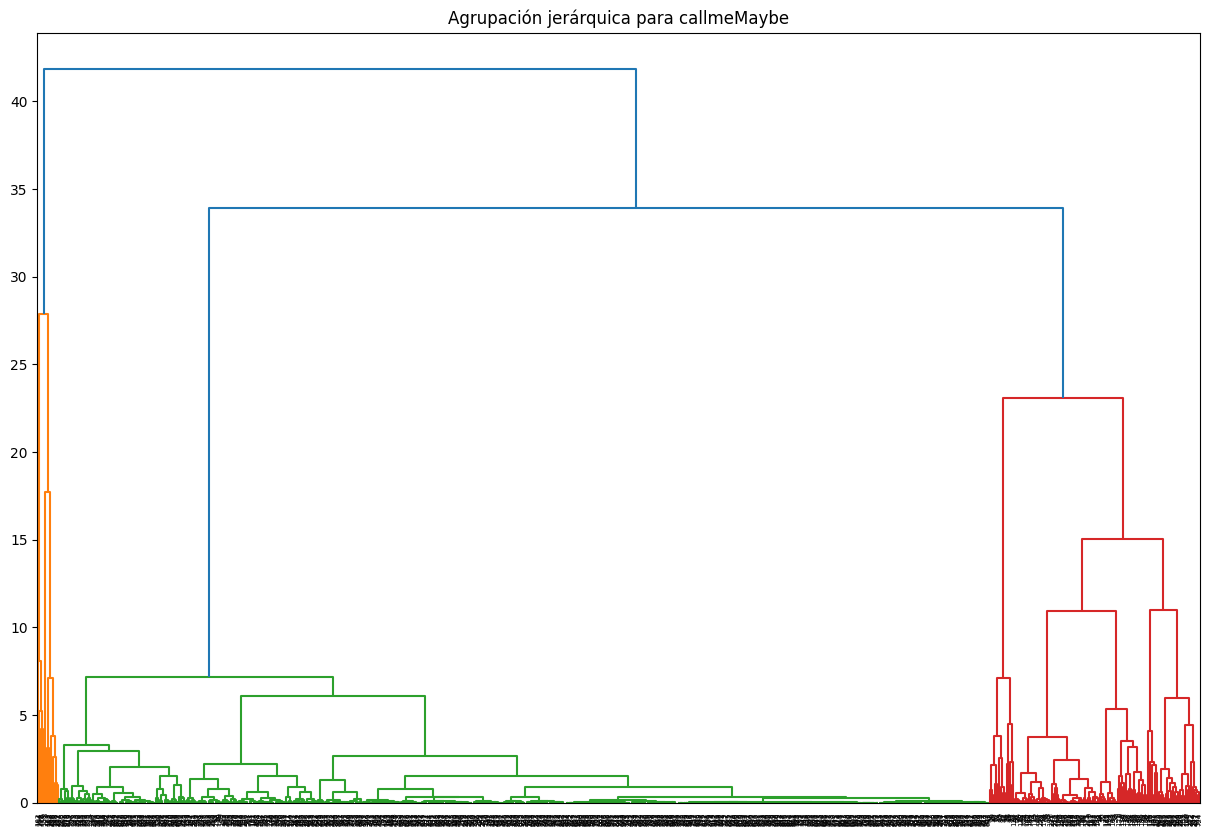

In [249]:
#dendrograma para saber cuantos clusters 
linked = linkage(x_sc, method ='ward')
plt.figure(figsize=(15,10))
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para callmeMaybe')
plt.show()

4 grupos son los que se usaran para el clustering 

In [264]:
km = KMeans(n_clusters = 4,random_state = 0 )
labels = km.fit_predict(x_sc)
data_operadores_kmeans['cluster_km'] = labels 
print(data_operadores_kmeans)

      operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
147        937860         30         1648          54            5.0   
148        969272          7          382          54            1.0   
149        947642         17          902          53            0.0   
150        939470         14          748          53            0.0   
151        932500         23         1175          51            0.0   
...           ...        ...          ...         ...            ...   
1087       947306          1            1           1            0.0   
1088       919896          3            5           1            1.0   
1089       919956         11           12           1            0.0   
1090       946468          1            1           1            0.0   
1091       925106         14           21           1            0.0   

     direction  call_duration_in  total_call_duration_in  time_wating_in  \
147         in           31529.0                 33473.0   

In [266]:
operadores_grupos = data_operadores_kmeans.groupby('cluster_km').mean()
print(operadores_grupos)

              operator_id  solo_date  calls_count  pro_llam_d  missing_calls  \
cluster_km                                                                     
0           925805.398126  14.140515   117.343091    6.898126       0.343091   
1           935237.818182  40.000000   679.000000   15.818182      22.272727   
2           909668.891892  51.608108  1659.864865   34.040541       1.405405   
3           917906.666667  58.666667  1162.166667   21.166667       2.833333   

            call_duration_in  total_call_duration_in  time_wating_in  \
cluster_km                                                             
0                3294.440281             3741.347775      446.907494   
1               51980.363636            61085.363636     9105.000000   
2               36563.108108            40113.702703     3550.594595   
3              101432.333333           136246.833333    34814.500000   

              calls_out  
cluster_km               
0             87.510539  
1       

### el cluster 3 es el que tiene el promedio de tiempo de espera más alto, muy por encima de los otros, tambien tiene el promedio más bajo en llamadas salientes, son operadores que tienen en promedio 58 dias en la empresa. Con un promedio de llamadas diarias de 21 llamdas diarias, para fines de nuestro analisis podemos definir que los operadores mas ineficientes son los que pertenecen al grupo 3. No tienen muchas llamadas perdidas pero aun asi son los segundos con el peor rendimiento en este campo .

In [278]:
#id de operadores que se consideran ineficiente 
operadores_ineficientes = data_operadores_kmeans[data_operadores_kmeans['cluster_km'] == 3]
print(operadores_ineficientes)
print(len(operadores_ineficientes))
print(len(data_operadores_kmeans))

     operator_id  solo_date  calls_count  pro_llam_d  missing_calls direction  \
203       919794         31         1157          37            1.0        in   
249       919790         59         1599          27            0.0        in   
301       919554         64         1192          18           11.0        in   
305       919552         63         1150          18            1.0        in   
351       919792         56          818          14            1.0        in   
360       908958         79         1057          13            3.0        in   

     call_duration_in  total_call_duration_in  time_wating_in  calls_out  \
203           88517.0                120753.0         32236.0       21.0   
249          104959.0                157754.0         52795.0       23.0   
301          113121.0                151320.0         38199.0       11.0   
305          135715.0                172733.0         37018.0       63.0   
351           62408.0                 85050.0       

In [270]:
# porcentaje de operadores ineficientes de operadores normales 
print('',f"{((len(operadores_ineficientes)/len(data_operadores_kmeans))*100):.3f}",'%')


 0.635 %


no tenemos ni un 1% de operadores ineficientes 

Ahora procedera ha hacer una prueba estadistica donde comprobaremos si existe diferecia estadistica comprobable entre los operadores eficientes e ineficientes. Aplicare una prueba no parametrica, como mann-whitney u test ya que tenemos muestras pequeñas y compara si dos grupos son significativamente diferentes.

### h0- No existe diferencia estadistica significativa comprobable entre los operadores ineficientes y los normales
### h1- Existe diferencia estadistica significativa comprobale entre los operadores ineficientes y los normales

In [274]:
# prueba con cada metrica 
# primero con llamadas perdidas 

alpha = .05/3
def prueba(valor1, valor2):
    results =mannwhitneyu(valor1, valor2)
    print('p-value',results.pvalue)
    if (results.pvalue < alpha):
        print('Hipótesis nula rechazada: Existe diferencia significativa entre los operadores ineficientes y los normales')
    else:
        print('No se pudo rechazar la hipótesis nula: No existe diferencia estadistica significativa comprobable entre los operadores ineficientes y los normales')
prueba(operadores_ineficientes['missing_calls'],data_operadores_kmeans['missing_calls'])

p-value 0.0004277925121552786
Hipótesis nula rechazada: Existe diferencia significativa entre los operadores ineficientes y los normales


In [275]:
prueba(operadores_ineficientes['time_wating_in'],data_operadores_kmeans['time_wating_in'])


p-value 2.3612806621023163e-05
Hipótesis nula rechazada: Existe diferencia significativa entre los operadores ineficientes y los normales


In [277]:
prueba(operadores_ineficientes['calls_out'],data_operadores_kmeans['calls_out'])

p-value 0.4866181560784191
No se pudo rechazar la hipótesis nula: No existe diferencia estadistica significativa comprobable entre los operadores ineficientes y los normales


Para las pruebas estadisticas de tiempo de espera y de llamadas perdidas existe diferencia estadistica comprobable ente estos operadores ineficientes y normales, solo en llamadas salientes no se pudo demostrar la diferencia estadistica. Puede que el tamaño de la prueba de solo 6 operadores este influyendo en el resultado de la prueba ya que si vemos los promedios de llamadas salientes del grupo 3, tienen rendimientos mucho menos optimos que los otros grupos.

In [279]:
#impresion de operadores ineficientes 
print(operadores_ineficientes['operator_id'].tolist())

[919794, 919790, 919554, 919552, 919792, 908958]


### Concluciones
#### Para poder indentificar a los operadores más ineficientes solo ya uqe comparar los promedios en las metricas claves y loq ue tengas peores rendimientos en más metricas seran catalogados como los más ineficientes.
#### Las principales caracteristicas que hacen nos dejan demostrar que los operadores del grupo 3 son ineficientes son:
#### -tienen los promedios más altos de tiempo de espera
#### -El menor rendimiento en llamdas salientes 
#### -Y el segundo puesto en el grupo con más llamadas entrantes perdidas.
#### se reafirma que son los operadores más ineficientes de los normales yq ue tienen una madures en la empresa en promedio de 58 dias, marcados con el promedio más alto de todos los grupos en esta metrica. Por lo que operadores con esta antiguedad no tendrian por que tener metricas tan malas.
#### Al final se pudo detectar que de nuestros operadores con comportamiento normal que realizan menos de 54 llamadas diarias solo el .635% es ineficiente. Solo 6 operadores de 945. Esto se llevo a cabo a traves de la eliminación de datos que se interpretaron como sospechosos, o sea los operadores que tienen mas de 54 llamadas diarias, estan tan lejos de la media que sus resultados peuden caer en lo sospechoso como previamente vimos(limite superior con promedio de llamadas diarias). El analisis podria cambiar si se decide no eliminar los datos atipicos y se pieansa que podria llegar a catalogarse a más operadores ineficientes, pero en base a mi analisis se considero que esto no era justo ya que no tenemos una perspectiva completa de los datos, y algunos valores que me llevaron a tomar la desicion de usar un limite superior como marge para definir a usuarios con comportamiento normal fue que operadores como el 925922 en la fecha 2019-10-03 21:00:00  realizo 544 llamdas  con una duracion total de 60890 segundos, lo que involucra más de 16 horas de trabajo para un operador, esta es la razón por al que se tuvo que filtrar a solo los operadores con comportamiento normales.

### Conclusiones de pruebas estadisticas 
#### Aunque la prueba estadística no encontró diferencia significativa en llamadas salientes (p = 0.487), el análisis descriptivo sugiere que el grupo ineficiente tiene promedios más bajos. Este resultado podría estar limitado por el pequeño tamaño del grupo ineficiente (n=6), lo que reduce el poder estadístico de la prueba. Con los otras metricas la prueba estadistica nos indica que si existe diferencia estadistica, lo que nos permite asegura que no es considencia que los operadores ineficientes tengas más timepos de espera y llamadas perdidas.

### Recomendaciones generales 
#### A los operadores ineficientes segun estos estandares id_operator = [919794, 919790, 919554, 919552, 919792, 908958], hablar con ellos y comentarles que se tienen que tener mejor metricas, ya que son operadores maduros y su rendimiento puedo ser mucho mejor. 
#### Crear un plan para que los operadores que haigan en ineficiencia puedan mejorar su metricas en un tiempo establecido y si eso no sucede, optar por ya no seguir renovando contratos con estos operadores. 
#### Establecer un tiempo de capacitación para los empleados nuevos, ya que en este tiempo no pueden ser evaluados como ineficientes o eficientes ya que no tienen todas las herramientas para poder desembolverse igual que los operadores maduros.
#### Sobre los operadores que tienen muy buenos rendimientos, mas de 54 llamadas al dia, crear una nueva forma de catalogarlos o tener más información sobre ellos, ya que muchos de sus numeros dan a entender que es un grupo de operadores bajo un mismo id, ya que las metricas estan muy infladas, si es este el caso, podemos descomponer a los equipos con id personalizados pero que esten adentro de un subgrupo que los identifique como un grupo.
#### Recomiendo hacer este ejercicio de manera mensual con los datos actulizados para saber si un operador que era eficiente llega a caer en lo ineficiente y ver cuales son las razones de esto. Esto nos ayudara a que podamos encontrar patrones que hace a los operadores ineficientes y tratar de evitar esto en medida de lo posible, para que cada vez allá menos operadores ineficientes.
#### Sobre las metrocas que se estan usando para evaluar a los operadores ineficientes agreagria la antiguedad de los operadores ya que a mi parecer es una metrica clabe para entender el comportamiento de los operadores.